# Simple grokking demo with superposition

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [2]:
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
import rpy2.robjects as ro
import estimator.stable_estimators as se



In [3]:
# Import stuff
import torch as t
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import einops

np.float64(0.4857575499956982)

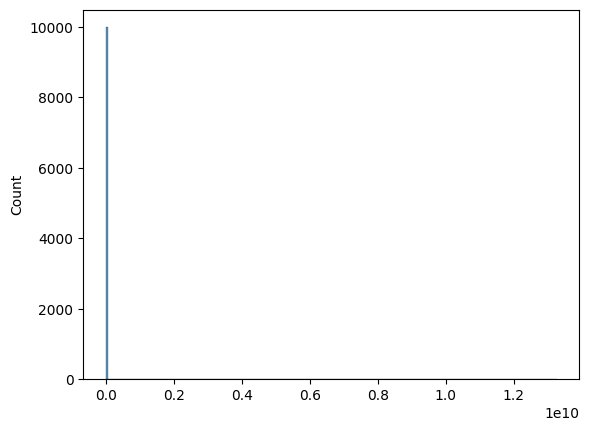

In [4]:
from scipy.stats import levy_stable
import seaborn as sns 
import matplotlib.pyplot as plt 
data = levy_stable.rvs(0.5,0.2, size = 10000)

sns.histplot(data)


se.robust_alpha_estimator(data)


## Generate Dataset

In [5]:
# Setup
p = 97
train_frac  = 0.3   #Fraction of the dataset used for training
device = t.accelerator.current_accelerator().type if t.accelerator.is_available() else "cpu"
device = "cpu"  # for the experiment we use cpu since mps cannot deal with float 64 apparently (which is important to prevent "slingshots")

device = t.device('mps' if t.backends.mps.is_available() else 'cpu')
print(f"Using {device} device")

Using mps device


In [6]:
a_vec = einops.repeat(t.arange(p),"i -> (i j)",j=p)
b_vec = einops.repeat(t.arange(p),"j -> (i j)",i=p)

# The dataset consists of pairs (x,y) with x = (a,b) and y = a+b mod p
# we randomly permute the dataset and split it into train and test dataset
dataset = t.stack([a_vec,b_vec],dim=1).to(device=device)
labels = (dataset[:,0] + dataset[:,1]) % p
indices = t.randperm(p**2)
train_indices = indices[:int(train_frac*p**2)]
test_indices = indices[int(train_frac*p**2):]

train_dataset = dataset[train_indices]
train_labels = labels[train_indices]

test_dataset = dataset[test_indices]
test_labels = labels[test_indices]
print(train_dataset)
print(train_labels)

tensor([[24, 94],
        [28, 89],
        [64, 18],
        ...,
        [10,  1],
        [ 3, 42],
        [95, 87]], device='mps:0')
tensor([21, 20, 82,  ..., 11, 45, 85], device='mps:0')


## Model architecture

We take a simple one-layer MLP with a learned embedding and unembedding
The architecture is:

0. Token: the tokens $t_0,t_1$ are one hot encoded d_vocab dimensional vectors and the input sequence is $$t = (t_0,t_1)^T$$
1. Embedding: The tokens are embedded in the d_model dimensional space by a learnable matrix W_E $$x_0 = Embed(t) = t @W_E$$
2. Concat: We concatenate the n_ctx(=2) vectors to form a d_model * n_ctx dimensional vector $$x_1 = flat(x_0)$$
3. MLP layer: A simple mlp with one hidden layer that is d_mlp = 4*d_model*n_ctx dimensional with ReLU activation function and bias:
$$x_2 = ReLU(x_1 @ W_{in} + b_{in}) @ W_{out}$$
4. Unembedding: a learned unembedding matrix W_U that maps back to the vocab.
$$x_3 = x_2 @ W_U$$

In [7]:
#Config for the MLP architecture
d_vocab = p   #The input consists of the numbers from 0 to p-1 and p for the equal sign
d_model = 128   #dimension of the model
n_ctx = 2       #context length (a,b,=) where = is encoded as 97
d_mlp = 2 * d_model * n_ctx     #hidden dimension of the MLP
act_type = "ReLU"   #or GeLU

In [8]:
from simple_models import SimpleMLP

In [9]:
#test
from random import randint

est = {}

layers = ["layer1", "layer2", "layer3"]

for epoch in range(10): 
    for layer in layers: 
        x = randint(0,100)
        if layer not in est: 
            est[layer] = []
        est[layer].append(x)

est

{'layer1': [49, 64, 57, 47, 65, 21, 48, 32, 27, 11],
 'layer2': [35, 73, 45, 4, 94, 73, 59, 32, 54, 22],
 'layer3': [64, 33, 4, 84, 63, 70, 72, 92, 51, 55]}

In [10]:
model = SimpleMLP(d_model,d_vocab,n_ctx,act_type).to(device=device)


def estimate_alpha_weights(model, result_dict):

    for name, param in model.named_parameters():
        if "weight" in name or "W_" in name:
            w = param.detach().flatten().cpu().numpy()
            alpha = se.robust_alpha_estimator(w)

            if name not in result_dict:
                result_dict[name] = []

            result_dict[name].append(alpha)




## Training

In [11]:
from torch.utils.data import DataLoader, TensorDataset

import tqdm.auto as tqdm

/Users/janikwahrheit/anaconda3/envs/BachelorThesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
#training parameters
n_epoch = 20000
lr = 1e-3
wd = 1.
DATA_SEED = 346
betas = (0.9,0.98)

In [13]:
# Define optimizer
optimizer = t.optim.AdamW(model.parameters(),lr=lr, betas=betas,weight_decay=wd)

In [14]:
#Define cross entropy loss
def loss_fn(logits,labels):
    if len(logits.shape) == 3:
        logits = logits[:,-1]
    # logits = logits.to(t.float64)   #change to 64 to prevent slingshots
    logits = logits.float()
    log_probs = logits.log_softmax(dim=-1)
    correct_log_probs = log_probs.gather(dim=-1,index = labels[:,None])[:,0]
    return -correct_log_probs.mean()

In [15]:
train_losses = []
test_losses = []

est_alpha = {}
for epoch in tqdm.tqdm(range(n_epoch)):
    train_logits = model(train_dataset)
    train_loss = loss_fn(train_logits,train_labels)
    train_loss.backward()
    train_losses.append(train_loss.item())
    optimizer.step()
    optimizer.zero_grad()
    with t.inference_mode():
        test_logits = model(test_dataset)
        test_loss = loss_fn(test_logits,test_labels)
        test_losses.append(test_loss.item())

    if ((epoch)%100)==0:
        print(f"Epoch {epoch} Train Loss {train_loss.item()} Test loss {test_loss.item()}")
        estimate_alpha_weights(model, est_alpha)

  0%|          | 0/20000 [00:00<?, ?it/s]

Epoch 0 Train Loss 4.584303379058838 Test loss 4.588654041290283


  0%|          | 92/20000 [00:02<04:26, 74.68it/s] 

Epoch 100 Train Loss 0.8289215564727783 Test loss 9.0565824508667


  1%|          | 201/20000 [00:04<06:37, 49.87it/s]

...

 99%|█████████▉| 19795/20000 [05:03<00:03, 62.87it/s]

Epoch 19800 Train Loss 2.625814374823676e-07 Test loss 3.8073849850661645e-07


 99%|█████████▉| 19899/20000 [05:05<00:01, 54.12it/s]

Epoch 19900 Train Loss 2.629193716074951e-07 Test loss 3.7840391087229364e-07


100%|██████████| 20000/20000 [05:07<00:00, 65.13it/s]


In [16]:
len(np.arange(0, 20000, 100).tolist())

200

## Plot results

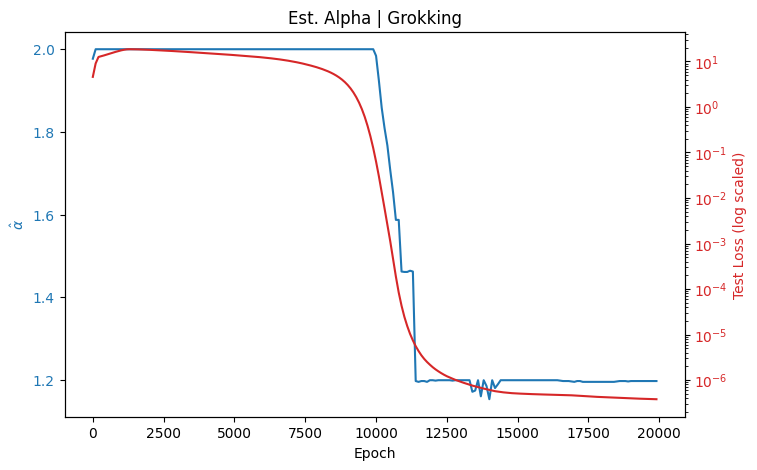

In [21]:
from itertools import islice
est_alpha

x = 2
key_x = next(islice(est_alpha.keys(), x, x+1))
alpha_est = est_alpha[key_x]

step_100 = np.arange(0, len(test_losses), 100)
test_losses_100 = np.array(test_losses)[step_100]


epochs = np.arange(0, 20000, 100).tolist()


fig, ax1 = plt.subplots(figsize=(8,5))

# linke y-Achse: alpha
color1 = "tab:blue"
ax1.set_xlabel("Epoch")
ax1.set_ylabel(r"$\hat\alpha$", color=color1)
sns.lineplot(x=epochs, y=alpha_est, ax=ax1, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# rechte y-Achse: train loss
ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Test Loss (log scaled)", color=color2)
sns.lineplot(x=epochs, y=test_losses_100, ax=ax2, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yscale("log")

plt.title("Est. Alpha | Grokking")
plt.show()




NameError: name 'test_losses_100' is not defined

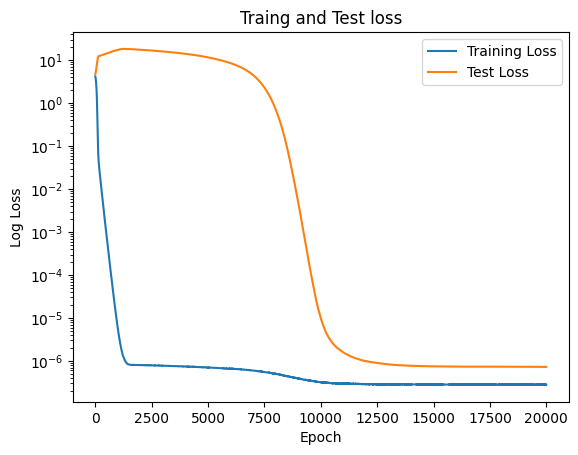

In [66]:
import matplotlib.pyplot as plt
plt.plot(train_losses,label="Training Loss")
plt.plot(test_losses,label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.yscale("log")
plt.title("Traing and Test loss")
plt.legend()
plt.show()

## Reverse Engineering
The goal is to look at the learned weights of the network and try to reverse engineer what the network is doing.

In [19]:
import scipy

### Embedding

In [23]:
W_E = model.embed.W_E.detach().numpy()
print(W_E.shape)

(128, 97)


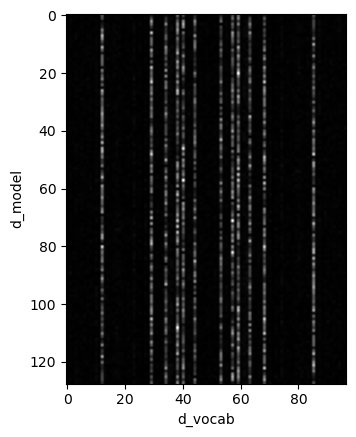

In [24]:
x = scipy.fft.fft2(W_E)
x = np.absolute(x)
max_x = np.max(x)
x = x/max_x
plt.imshow(x,cmap="grey")
plt.xlabel("d_vocab")
plt.ylabel("d_model")
plt.show()